In [1]:
from pathlib import Path
from typing import List, Tuple

import pandas as pd

In [8]:
BASE_DIR = Path("/Users/chensi/Desktop/MIDS/Fall 2025/capstone project")
USA_DIR = BASE_DIR / "USA"
OUTPUT_DIR = BASE_DIR / "data exploration" / "processed_real"
OUTPUT_DIR.mkdir(exist_ok=True)

PII_COLUMNS = {
    "IPAddress",
    "RecipientLastName",
    "RecipientFirstName",
    "RecipientEmail",
    "ExternalReference",
    "LocationLatitude",
    "LocationLongitude",
}
DROP_COLUMNS = PII_COLUMNS | {"Status"}


def _build_participant_id(df: pd.DataFrame, candidates: List[str]) -> pd.Series:
    series = pd.Series([None] * len(df))
    for col in candidates:
        if col in df.columns:
            series = series.fillna(df[col])
    return series


def load_usa_file(filename: str, timepoint: int) -> pd.DataFrame:
    path = USA_DIR / filename
    df = pd.read_csv(path, skiprows=[1], dtype=str, on_bad_lines="skip")
    df = df[~df["StartDate"].astype(str).str.contains("ImportId", na=False)]
    df = df.drop(
        columns=[c for c in df.columns if str(c).startswith("Unnamed:")],
        errors="ignore",
    )

    id_candidates = ["ProlificID", "PROLIFIC_PID", "PROLIFIC ID", "ResponseId"]
    df["ParticipantID"] = _build_participant_id(df, id_candidates)

    finished_mask = df["Finished"].astype(str).str.lower().isin({"true", "1", "yes"})
    consent_mask = (
        df["InformedConsent"].astype(str).str.contains("consent", case=False, na=False)
    )
    df = df[finished_mask & consent_mask].copy()
    df = df.drop(columns=DROP_COLUMNS, errors="ignore")

    df.insert(0, "Timepoint", timepoint)
    df.insert(0, "Country", "USA")
    return df


def combine_frames(frames: List[pd.DataFrame], label: str) -> pd.DataFrame:
    if not frames:
        raise ValueError(f"No data found for {label}")
    combined = pd.concat(frames, ignore_index=True)
    combined["ParticipantID"] = combined["ParticipantID"].astype(str).str.strip()
    combined["Timepoint"] = combined["Timepoint"].astype(int)
    return combined.drop_duplicates(
        subset=["Country", "Timepoint", "ParticipantID"], keep="first"
    )


def build_summary(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby(["Country", "Timepoint"])["ParticipantID"]
        .agg(rows="count", unique_participants="nunique")
        .reset_index()
        .sort_values(["Country", "Timepoint"])
    )


def main() -> None:
    usa_files: List[Tuple[str, int]] = [
        ("Dream Initial Survey_March 8, 2024_18.39.csv", 1),
        ("Dream Follow Up 1_April 14, 2024_22.21.csv", 2),
        ("Dream Follow Up 2_June 3, 2024_17.00.csv", 3),
        ("Dream Follow Up 3_June 20, 2024_18.52.csv", 4),
        ("Dream Follow Up 4_August 18, 2024_19.10.csv", 5),
    ]

    usa_frames = [load_usa_file(fname, tp) for fname, tp in usa_files]
    usa_combined = combine_frames(usa_frames, "USA")
    summary = build_summary(usa_combined)

    usa_path = OUTPUT_DIR / "usa_cleaned_longitudinal.csv"
    summary_path = OUTPUT_DIR / "data_summary.csv"
    usa_combined.to_csv(usa_path, index=False)
    summary.to_csv(summary_path, index=False)

    print(f"Saved USA data -> {usa_path}")
    print("\nSummary by timepoint:")
    print(summary.to_string(index=False))


main()

Saved USA data -> /Users/chensi/Desktop/MIDS/Fall 2025/capstone project/data exploration/processed_real/usa_cleaned_longitudinal.csv

Summary by timepoint:
Country  Timepoint  rows  unique_participants
    USA          1   576                  576
    USA          2   499                  499
    USA          3   448                  448
    USA          4   422                  422
    USA          5   397                  397


Shape: (2342, 84)


/var/folders/gj/nvvqk8_x3l56pvm3zf2l8g_r0000gn/T/ipykernel_19382/2291160189.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  scored = cleaned.replace(map_dict)
/var/folders/gj/nvvqk8_x3l56pvm3zf2l8g_r0000gn/T/ipykernel_19382/2291160189.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  scored = cleaned.replace(map_dict)


,Timepoint,PHQ9_Score,GAD7_Score
0,1,0.0,0.0
1,1,3.0,10.0
2,1,9.0,9.0
3,1,7.0,7.0
4,1,5.0,6.0


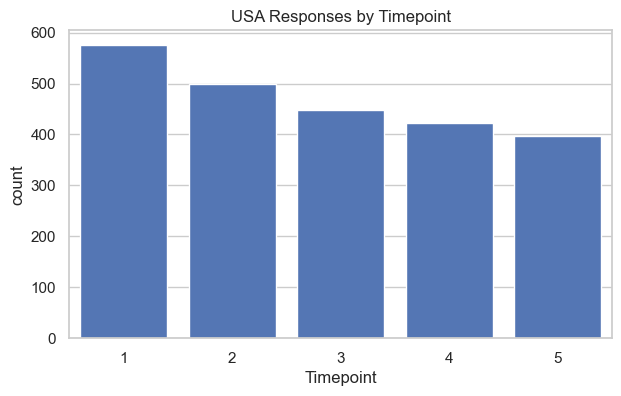

Saved -> /Users/chensi/Desktop/MIDS/Fall 2025/capstone project/data exploration/processed_real/figs_usa/usa_counts_timepoint.png


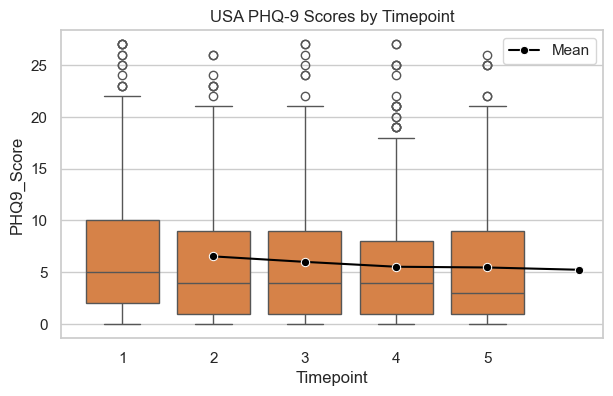

Saved -> /Users/chensi/Desktop/MIDS/Fall 2025/capstone project/data exploration/processed_real/figs_usa/usa_phq9_timepoint.png


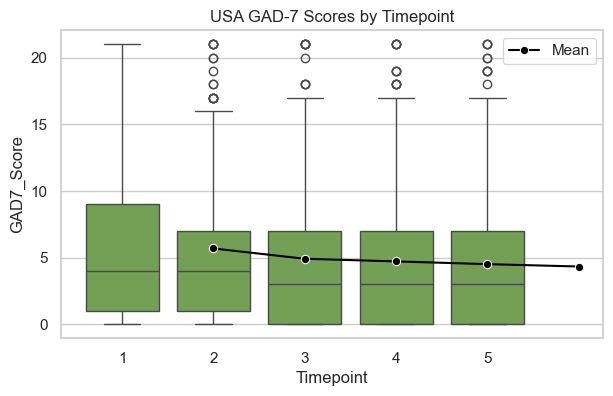

Saved -> /Users/chensi/Desktop/MIDS/Fall 2025/capstone project/data exploration/processed_real/figs_usa/usa_gad7_timepoint.png


In [12]:
from pathlib import Path
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
BASE = Path("/Users/chensi/Desktop/MIDS/Fall 2025/capstone project/data exploration")
usa_path = BASE / "processed_real" / "usa_cleaned_longitudinal.csv"
FIG_DIR = BASE / "processed_real" / "figs_usa"
FIG_DIR.mkdir(exist_ok=True)

LIKERT_MAP = {
    "Not At All": 0,
    "Several Days": 1,
    "More Than Half The Days": 2,
    "Nearly Every Day": 3,
}

df = pd.read_csv(usa_path)
df["Timepoint"] = df["Timepoint"].astype(int)

phq_cols = [c for c in df.columns if c.startswith("PHQ_Bothered_")]
gad_cols = [c for c in df.columns if c.startswith("GAD_Bothered_")]


def score_scale(frame, cols, map_dict):
    cleaned = frame[cols].apply(lambda s: s.str.strip().str.title())
    scored = cleaned.replace(map_dict)
    return scored.apply(pd.to_numeric, errors="coerce").sum(axis=1, min_count=1)


if phq_cols:
    df["PHQ9_Score"] = score_scale(df, phq_cols, LIKERT_MAP)
if gad_cols:
    df["GAD7_Score"] = score_scale(df, gad_cols, LIKERT_MAP)

print("Shape:", df.shape)
display(df[["Timepoint", "PHQ9_Score", "GAD7_Score"]].head())


def save_show(fig, name):
    out = FIG_DIR / name
    fig.savefig(out, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved -> {out}")


fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x="Timepoint", color="#4472c4", ax=ax)
ax.set_title("USA Responses by Timepoint")
save_show(fig, "usa_counts_timepoint.png")

if "PHQ9_Score" in df:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.boxplot(data=df, x="Timepoint", y="PHQ9_Score", color="#ed7d31", ax=ax)
    sns.lineplot(
        df.groupby("Timepoint")["PHQ9_Score"].mean().reset_index(),
        x="Timepoint",
        y="PHQ9_Score",
        marker="o",
        color="black",
        ax=ax,
        label="Mean",
    )
    ax.set_title("USA PHQ-9 Scores by Timepoint")
    save_show(fig, "usa_phq9_timepoint.png")

if "GAD7_Score" in df:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.boxplot(data=df, x="Timepoint", y="GAD7_Score", color="#70ad47", ax=ax)
    sns.lineplot(
        df.groupby("Timepoint")["GAD7_Score"].mean().reset_index(),
        x="Timepoint",
        y="GAD7_Score",
        marker="o",
        color="black",
        ax=ax,
        label="Mean",
    )
    ax.set_title("USA GAD-7 Scores by Timepoint")
    save_show(fig, "usa_gad7_timepoint.png")

Shape: (2342, 82)


,Country,Timepoint,StartDate,EndDate,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,DistributionChannel,...,More_CoffeeTime,More_Stimulants,More_AlcoholFreq,More_AlcoholAmount,More_Cigarettes,More_LivingSituation,More_Pets,ProlificID,PROLIFIC_PID,ParticipantID
0,USA,1,3/1/24 17:38,3/1/24 17:46,100,517,True,3/1/24 17:46,R_3wRkyxtsjzYqici,anonymous,...,NaN,No,1-2 times in the past year,1-2 drinks,I have never smoked cigareets,Living with partner/family,Yes,5cb6527cdcd7180015d0a463,5cb6527cdcd7180015d0a463,5cb6527cdcd7180015d0a463
1,USA,1,3/1/24 17:44,3/1/24 17:49,100,342,True,3/1/24 17:49,R_762XmUHiIpKFk5V,anonymous,...,After 4 pm,No,3-11 times in the past year,1-2 drinks,I have never smoked cigareets,Living with partner/family,No,65bda9a2211c74f0d87b4f97,65bda9a2211c74f0d87b4f97,65bda9a2211c74f0d87b4f97
2,USA,1,3/1/24 17:44,3/1/24 17:50,100,307,True,3/1/24 17:50,R_3zkIYTiT5Vb2xzz,anonymous,...,Before 12pm,No,1-2 times in the past year,1-2 drinks,I have never smoked cigareets,Living alone,No,5d58a7bc257b370018265ffe,5d58a7bc257b370018265ffe,5d58a7bc257b370018265ffe
3,USA,1,3/1/24 17:43,3/1/24 17:52,100,567,True,3/1/24 17:52,R_3Uc33LeOoWB3dw9,anonymous,...,Before 12pm,No,Never,NaN,I have never smoked cigareets,Living with partner/family,No,65b94d4dc871916672fce70d,65b94d4dc871916672fce70d,65b94d4dc871916672fce70d
4,USA,1,3/1/24 17:45,3/1/24 17:55,100,581,True,3/1/24 17:55,R_3xoJn9YIytHgUDv,anonymous,...,NaN,No,Never,NaN,I have never smoked cigareets,Living with partner/family,No,6500a84f0a4f87687fa51a20,6500a84f0a4f87687fa51a20,6500a84f0a4f87687fa51a20


Missing (%):
 More_NightmareFreq      75.4
Demo_Age                75.4
Sleep_Morning/Eve       75.4
More_Childhood_1        75.4
Demo_Gender             75.4
Demo_Student            75.4
Demo_Education          75.4
Dream_TalkWhom          71.0
MorNightmaredistress    63.7
More_BadDreamReality    44.4
More_AlcoholAmount      41.9
More_DreamDistress_1    38.6
Dream_Feelings          35.4
More_CoffeeCups         33.5
More_CoffeeTime         33.5
dtype: float64


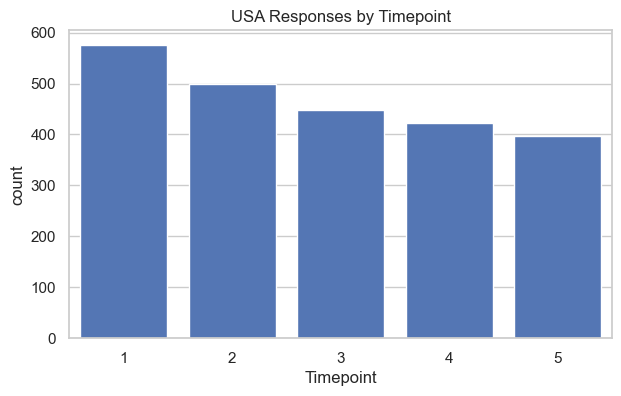

Saved -> /Users/chensi/Desktop/MIDS/Fall 2025/capstone project/data exploration/processed_real/figs_usa/usa_counts_timepoint.png


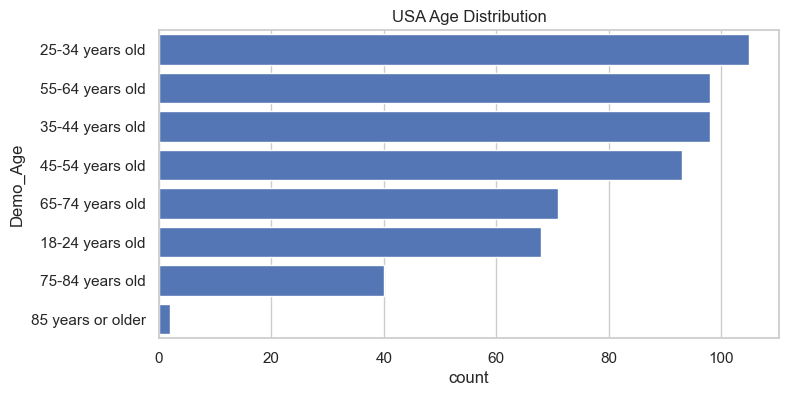

Saved -> /Users/chensi/Desktop/MIDS/Fall 2025/capstone project/data exploration/processed_real/figs_usa/usa_age_distribution.png


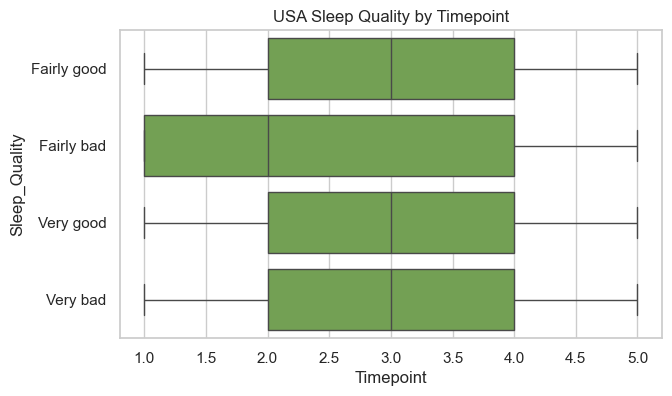

Saved -> /Users/chensi/Desktop/MIDS/Fall 2025/capstone project/data exploration/processed_real/figs_usa/usa_sleep_quality_timepoint.png


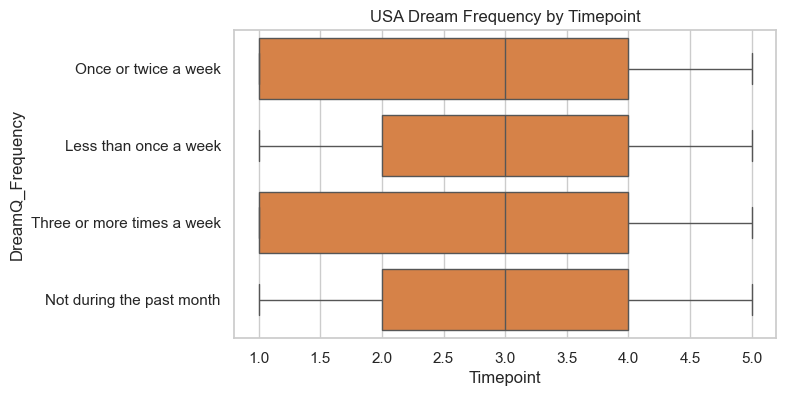

Saved -> /Users/chensi/Desktop/MIDS/Fall 2025/capstone project/data exploration/processed_real/figs_usa/usa_dream_freq_timepoint.png


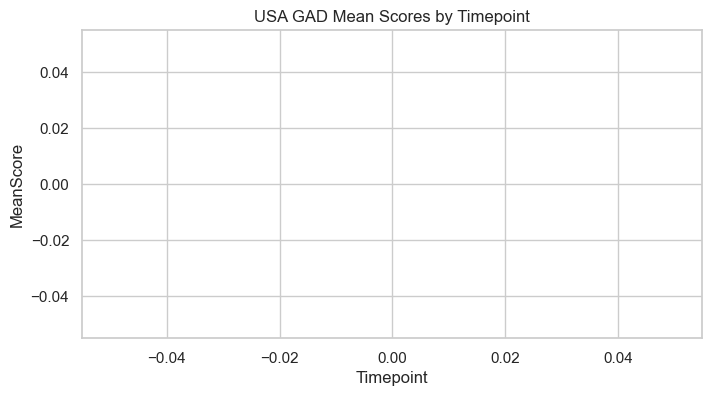

Saved -> /Users/chensi/Desktop/MIDS/Fall 2025/capstone project/data exploration/processed_real/figs_usa/usa_gad_means_timepoint.png


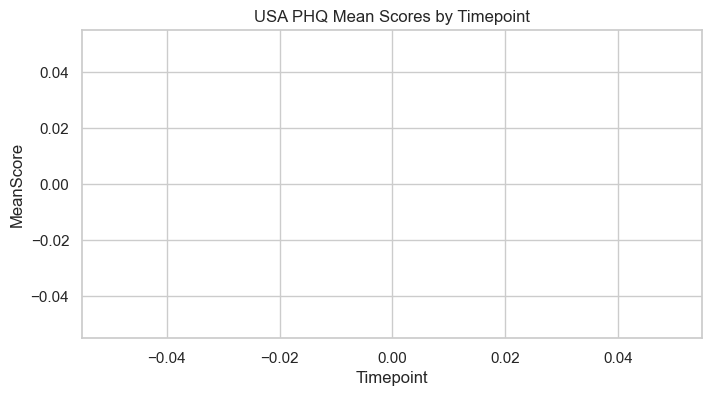

Saved -> /Users/chensi/Desktop/MIDS/Fall 2025/capstone project/data exploration/processed_real/figs_usa/usa_phq_means_timepoint.png


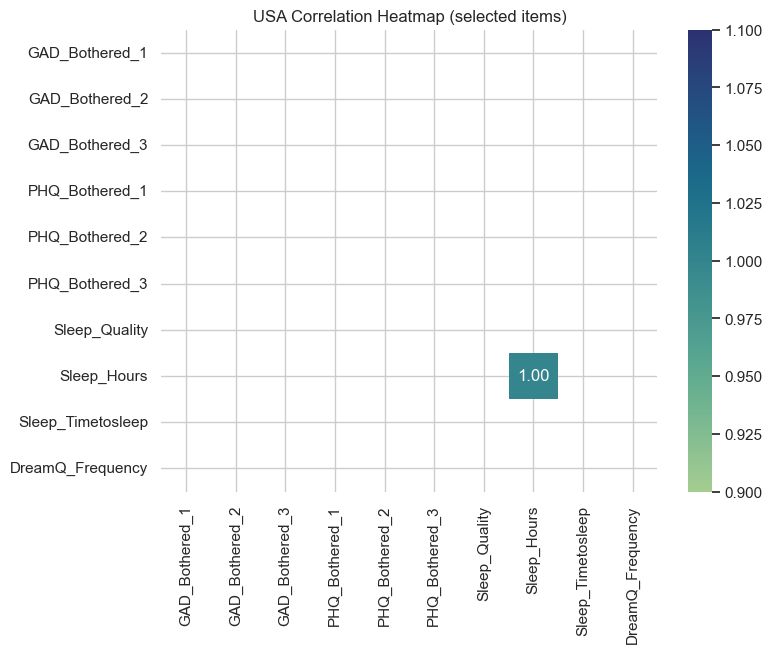

Saved -> /Users/chensi/Desktop/MIDS/Fall 2025/capstone project/data exploration/processed_real/figs_usa/usa_corr_heatmap.png


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="whitegrid")

BASE = Path("/Users/chensi/Desktop/MIDS/Fall 2025/capstone project/data exploration")
DATA_PATH = BASE / "processed_real" / "usa_cleaned_longitudinal.csv"
FIG_DIR = BASE / "processed_real" / "figs_usa"
FIG_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())
print(
    "Missing (%):\n",
    (df.isna().mean().sort_values(ascending=False) * 100).round(1).head(15),
)


# Helper to save/show plots
def save_show(fig, name):
    out = FIG_DIR / name
    fig.savefig(out, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved -> {out}")


# Responses by timepoint
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x="Timepoint", color="#4472c4", ax=ax)
ax.set_title("USA Responses by Timepoint")
save_show(fig, "usa_counts_timepoint.png")

# Age distribution (if present)
if "Demo_Age" in df.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    order = df["Demo_Age"].dropna().value_counts().index
    sns.countplot(data=df, y="Demo_Age", order=order, color="#4472c4", ax=ax)
    ax.set_title("USA Age Distribution")
    save_show(fig, "usa_age_distribution.png")

# Sleep quality over time
if "Sleep_Quality" in df.columns:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.boxplot(data=df, x="Timepoint", y="Sleep_Quality", ax=ax, color="#70ad47")
    ax.set_title("USA Sleep Quality by Timepoint")
    save_show(fig, "usa_sleep_quality_timepoint.png")

# Dream frequency over time
if "DreamQ_Frequency" in df.columns:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.boxplot(data=df, x="Timepoint", y="DreamQ_Frequency", ax=ax, color="#ed7d31")
    ax.set_title("USA Dream Frequency by Timepoint")
    save_show(fig, "usa_dream_freq_timepoint.png")

# GAD/PHQ means by timepoint
gad_cols = [c for c in df.columns if c.startswith("GAD_Bothered_")]
phq_cols = [c for c in df.columns if c.startswith("PHQ_Bothered_")]
for label, cols in [("GAD", gad_cols), ("PHQ", phq_cols)]:
    if cols:
        df_num = df.copy()
        df_num[cols] = df_num[cols].apply(pd.to_numeric, errors="coerce")
        agg = (
            df_num.groupby("Timepoint")[cols]
            .mean()
            .reset_index()
            .melt(id_vars="Timepoint", var_name="Item", value_name="MeanScore")
        )
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.lineplot(data=agg, x="Timepoint", y="MeanScore", marker="o", ax=ax)
        ax.set_title(f"USA {label} Mean Scores by Timepoint")
        save_show(fig, f"usa_{label.lower()}_means_timepoint.png")

# Correlation heatmap for selected numerics
num_cols = (
    gad_cols[:3]
    + phq_cols[:3]
    + [
        c
        for c in [
            "Sleep_Quality",
            "Sleep_Hours",
            "Sleep_Timetosleep",
            "DreamQ_Frequency",
        ]
        if c in df.columns
    ]
)
if num_cols:
    df_num = df[num_cols].apply(pd.to_numeric, errors="coerce")
    corr = df_num.corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="crest", ax=ax)
    ax.set_title("USA Correlation Heatmap (selected items)")
    save_show(fig, "usa_corr_heatmap.png")